Training on device: cuda
Loading MNIST data...

Starting Training with He Initialization...

Epoch      | Train Loss   | Train Acc    | Test Loss    | Test Acc    
-----------------------------------------------------------------
Epoch 1    | 0.2278       | 93.33     % | 0.1332       | 95.61     %
Epoch 2    | 0.0902       | 97.27     % | 0.0885       | 97.14     %
Epoch 3    | 0.0612       | 98.09     % | 0.0772       | 97.56     %
Epoch 4    | 0.0467       | 98.50     % | 0.0794       | 97.62     %
Epoch 5    | 0.0378       | 98.79     % | 0.0724       | 97.81     %
Epoch 6    | 0.0303       | 98.97     % | 0.0823       | 97.72     %
Epoch 7    | 0.0261       | 99.18     % | 0.0773       | 98.00     %
Epoch 8    | 0.0247       | 99.17     % | 0.0766       | 97.98     %
Epoch 9    | 0.0200       | 99.33     % | 0.0920       | 97.68     %
Epoch 10   | 0.0182       | 99.42     % | 0.1216       | 97.13     %

Training complete!


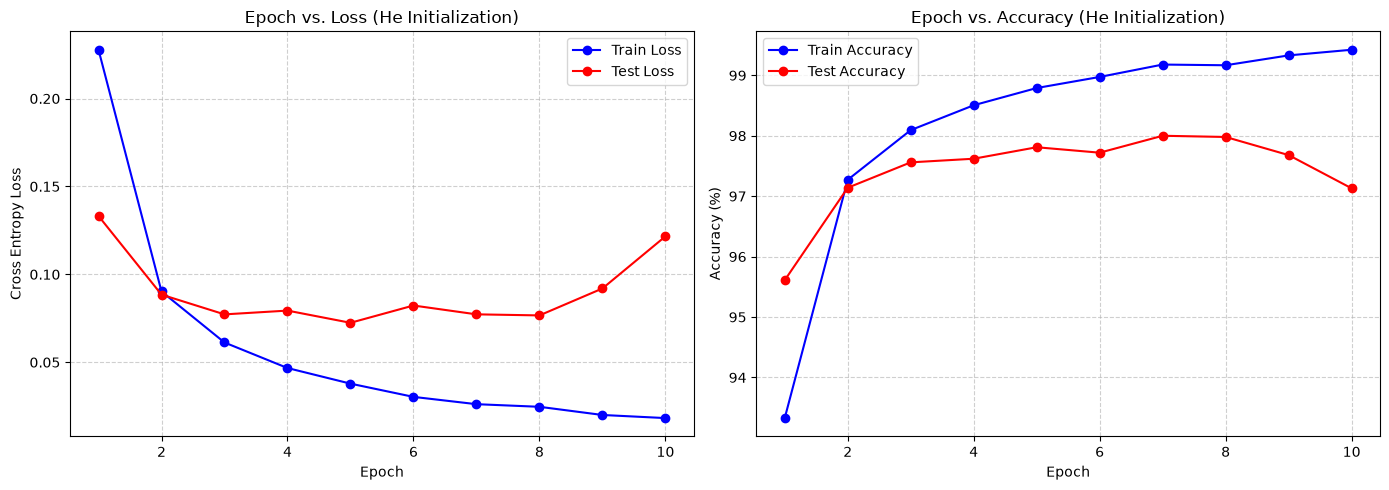

In [1]:
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
import matplotlib.pyplot as plt


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Training on device: {device}")
print("Loading MNIST data...")

train_df = pd.read_csv('mnist_train.csv')
test_df = pd.read_csv('mnist_test.csv')

X_train_tensor = torch.tensor(train_df.iloc[:, 1:].values / 255.0, dtype=torch.float32)
y_train_tensor = torch.tensor(train_df.iloc[:, 0].values, dtype=torch.long) 
X_test_tensor = torch.tensor(test_df.iloc[:, 1:].values / 255.0, dtype=torch.float32)
y_test_tensor = torch.tensor(test_df.iloc[:, 0].values, dtype=torch.long)

batch_size = 64
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

def apply_he_initialization(m):
    """
    Applies He (Kaiming) Normal initialization to Linear layers.
    Optimal for networks using ReLU activations.
    """
    if isinstance(m, nn.Linear):
       
        nn.init.kaiming_normal_(m.weight, nonlinearity='relu')
        # Initialize biases to 0
        if m.bias is not None:
            nn.init.zeros_(m.bias)


model_init = nn.Sequential(
    nn.Linear(784, 256),
    nn.ReLU(),
    nn.Linear(256, 128),
    nn.ReLU(),
    nn.Linear(128, 64),
    nn.ReLU(),
    nn.Linear(64, 10) 
).to(device)

# --------------------------------------
model_init.apply(apply_he_initialization)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model_init.parameters(), lr=0.001)

epochs = 10
print("\nStarting Training with He Initialization...\n")
print(f"{'Epoch':<10} | {'Train Loss':<12} | {'Train Acc':<12} | {'Test Loss':<12} | {'Test Acc':<12}")
print("-" * 65)

train_losses, train_accuracies = [], []
test_losses, test_accuracies = [], []

for epoch in range(epochs):
    # --- TRAINING PHASE ---
    model_init.train() 
    running_train_loss = 0.0
    correct_train = 0
    total_train = 0
    
    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        
        optimizer.zero_grad()
        outputs = model_init(X_batch)
        
        loss = criterion(outputs, y_batch)
        loss.backward()
        optimizer.step()
        
        running_train_loss += loss.item() * X_batch.size(0)
        _, predicted = torch.max(outputs, 1)
        total_train += y_batch.size(0)
        correct_train += (predicted == y_batch).sum().item()
        
    avg_train_loss = running_train_loss / total_train
    train_acc = (correct_train / total_train) * 100


    model_init.eval() 
    running_test_loss = 0.0
    correct_test = 0
    total_test = 0
    
    with torch.no_grad(): 
        for X_batch, y_batch in test_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            
            outputs = model_init(X_batch)
            loss = criterion(outputs, y_batch)
            
            running_test_loss += loss.item() * X_batch.size(0)
            _, predicted = torch.max(outputs, 1)
            total_test += y_batch.size(0)
            correct_test += (predicted == y_batch).sum().item()
            
    avg_test_loss = running_test_loss / total_test
    test_acc = (correct_test / total_test) * 100
    
    train_losses.append(avg_train_loss)
    train_accuracies.append(train_acc)
    test_losses.append(avg_test_loss)
    test_accuracies.append(test_acc)
    
    print(f"Epoch {epoch+1:<4} | {avg_train_loss:<12.4f} | {train_acc:<10.2f}% | {avg_test_loss:<12.4f} | {test_acc:<10.2f}%")

print("\nTraining complete!")


plt.figure(figsize=(14, 5))
epochs_range = range(1, epochs + 1)


plt.subplot(1, 2, 1)
plt.plot(epochs_range, train_losses, label='Train Loss', color='blue', marker='o')
plt.plot(epochs_range, test_losses, label='Test Loss', color='red', marker='o')
plt.title('Epoch vs. Loss (He Initialization)')
plt.xlabel('Epoch')
plt.ylabel('Cross Entropy Loss')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)


plt.subplot(1, 2, 2)
plt.plot(epochs_range, train_accuracies, label='Train Accuracy', color='blue', marker='o')
plt.plot(epochs_range, test_accuracies, label='Test Accuracy', color='red', marker='o')
plt.title('Epoch vs. Accuracy (He Initialization)')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()